# Curve-Fitting — a quantitative teardown 🔬
### Optimise-then-validate · IS−OOS shrinkage vs grid size · HAC *t* + block bootstrap · alpha-vs-beta strip · synthetic null + positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survives_out_of_sample%3F: Busted](https://img.shields.io/badge/Survives_out_of_sample%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We quantify the optimisation mirage: how the best-of-grid in-sample Sharpe inflates with the search, how it fails to transfer out of sample on a no-edge tape, and how the one real-tape 'survivor' dissolves into market beta once we race it against buy-and-hold.

> ⚠️ **Not investment advice.** Real data: SPY daily total return 1993–2026 (as-of 2026-05-29, last full month); the offline core and tests run on a deterministic synthetic generator. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from curve_fitting import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE, "SPY"))

HAVE_REAL = _have_cache()

def real_series():
    px = data.load_real(ticker="SPY", fetch=False)
    asof = px.index.max().to_period("M").to_timestamp()   # drop the partial final month
    return px[px.index < asof]

print("real SPY cache present:", HAVE_REAL)


real SPY cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Null: IS Sharpe 0.94 → OOS -0.05 (HAC *t* = -0.15). Real SPY: OOS Sharpe 0.69 is beta (84% exposure); alpha vs buy-and-hold -6.1%/yr (*t* = -2.70). |
| **Tradability** | `MIRAGE` | The tuned winner trails buy-and-hold OOS (0.69 vs 0.92 Sharpe) while paying turnover. No edge to harvest. |
| **Survives out of sample?** | `BUSTED` | IS Sharpe rises with grid size (0.55 → 0.91) while OOS stays flat; the planted-trend control survives (IS 1.03 → OOS 1.13, *t* = 3.36). |

> 💡 In plain words: the maximum of many noisy backtests is biased upward, so the in-sample winner overstates the truth by an amount that grows with the search. Out of sample that excess is gone; what remains on a real tape is whatever beta a mostly-long rule inherited.

## 1 · The claim, steelmanned

Let $\{(f_i, s_i)\}_{i=1}^{N}$ be a grid of crossover windows, $\widehat{SR}^{IS}_i$ the in-sample Sharpe of pair $i$, and $i^\star = \arg\max_i \widehat{SR}^{IS}_i$ the crowned winner. Let $SR^{OOS}_{i^\star}$ be its out-of-sample Sharpe and $SR^{BH}$ buy-and-hold's.

- **H₁ (the winner has a real edge).** $\mathbb{E}[SR^{OOS}_{i^\star}] > 0$ and reflects the rule, not the market.
- **H₂ (the optimisation adds value).** The winner's OOS alpha over buy-and-hold is positive: $\mathbb{E}[r^{i^\star}_t - r^{BH}_t] > 0$.
- **H₃ (the in-sample Sharpe is informative).** $\widehat{SR}^{IS}_{i^\star}$ does not inflate with $N$ on a no-edge tape.

We find **H₁ rejected** (OOS reverts to noise on the null; the real-tape OOS is beta), **H₂ rejected** (real-tape alpha is significantly *negative*), and **H₃ rejected** (IS Sharpe rises monotonically-ish with $N$ while OOS is flat). The positive control confirms the test is not simply blind to signal.

## 2 · So what? — what rides on each answer

Lo & MacKinlay (1990) and the backtest-overfitting literature (Bailey, Borwein, López de Prado & Zhu 2014) show the best-of-$N$ statistic is biased upward by selection: the *expected maximum* of $N$ i.i.d. noise Sharpes grows roughly like $\sqrt{2\ln N}$ even when every true Sharpe is zero. The desk's contribution is to make that bias *visible and measurable* on a concrete rule — the IS−OOS shrinkage as a function of $N$ — and to show that the one case where the OOS number *doesn't* collapse is explained entirely by market beta, not by the search. The binary 'did the winner survive?' is a distraction; the *shrinkage* and the *beta-stripped alpha* are the result.

## 3 · How we'd know — the protocol

- **Rule.** Long-or-flat simple-MA crossover (long when fast MA > slow MA). One execution lag: the signal at close $t$ earns the return of $t+1$ (a single `shift`). Costs: one-way turnover × NAV at `cost_bps` per leg on $|\Delta\text{position}|$.
- **Grid.** 93 valid $(f, s)$ pairs with $f < s$, scored by in-sample annualised Sharpe.
- **Split.** Chronological 50/50 — tune on the first half, validate on the second; the OOS slice is never seen during tuning.
- **Inference.** Newey-West HAC *t* on the OOS mean daily return; circular block-bootstrap (Politis-Romano) 95% CI on the OOS Sharpe. Excess-of-cash returns; flat days are exactly 0.
- **Alpha vs beta.** A mostly-long timing rule inherits the asset's beta — we HAC-test the winner minus buy-and-hold to strip it.
- **Falsifier.** A *synthetic null* (random walk) where no rule has an edge — if the winner survives there, the test is broken. A *positive control* (planted trend) where it must survive — if it fails there, the test is blind. Both are deterministic and offline.
- **Mirage scope:** the synthetic null is a *machinery proof* of the bias, never market evidence; the Signal stamp is earned (here, denied) on the real tape and the beta strip.

## 4 · The teardown

### 4a · The null — best-of-93 on a random walk

The in-sample sweep crowns a pair with a handsome Sharpe; out of sample it is indistinguishable from zero (HAC *t*, block-bootstrap CI straddling zero).

winner (5, 50)  grid=93 pairs
IS Sharpe 0.94  ->  OOS Sharpe -0.05
OOS HAC t = -0.15   block-bootstrap 95% Sharpe CI [-0.65, +0.54]
shrinkage (IS - OOS) = +0.98


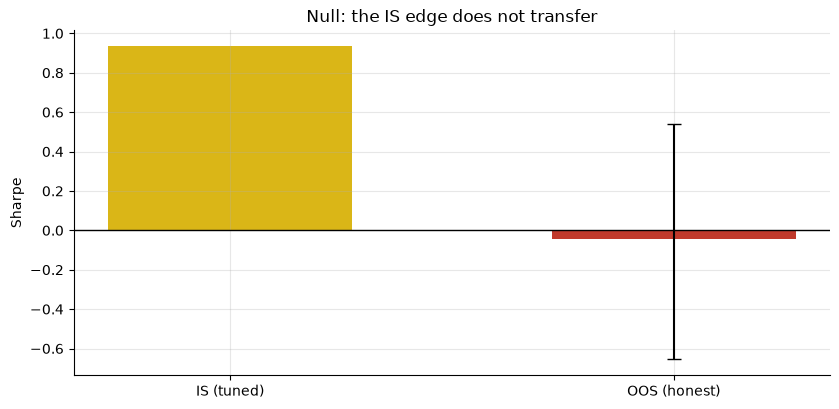

In [2]:
px_null, _ = data.synthetic_series(n_days=5000, trend_strength=0.0, trend_halflife=80, seed=348)
res_null = st.curve_fit_experiment(px_null, frac_is=0.5)
lo, hi = res_null['oos_ci']
print(f"winner {res_null['winner']}  grid={res_null['n_grid']} pairs")
print(f"IS Sharpe {res_null['is_sharpe']:.2f}  ->  OOS Sharpe {res_null['oos_sharpe']:+.2f}")
print(f"OOS HAC t = {res_null['oos_test']['tstat']:+.2f}   "
      f"block-bootstrap 95% Sharpe CI [{lo:+.2f}, {hi:+.2f}]")
print(f"shrinkage (IS - OOS) = {res_null['shrinkage']:+.2f}")
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.bar(['IS (tuned)', 'OOS (honest)'], [res_null['is_sharpe'], res_null['oos_sharpe']],
       color=[AMBER, RED], width=.55)
ax.errorbar(1, res_null['oos_sharpe'], yerr=[[res_null['oos_sharpe']-lo],[hi-res_null['oos_sharpe']]],
            fmt='none', ecolor='k', capsize=5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('Sharpe'); ax.set_title('Null: the IS edge does not transfer')
plt.tight_layout(); plt.show()

> 💡 In plain words: ~**0.98** of an in-sample Sharpe of ~**0.94** vanished out of sample, leaving **-0.05** (*t* = -0.15). On a market with no edge, the backtest measured the search, not the rule.

### 4b · The bias is a function of the search — IS−OOS shrinkage vs grid size

The expected maximum in-sample Sharpe grows with $N$ even under the null. Out of sample, the added height is pure selection and never arrives.

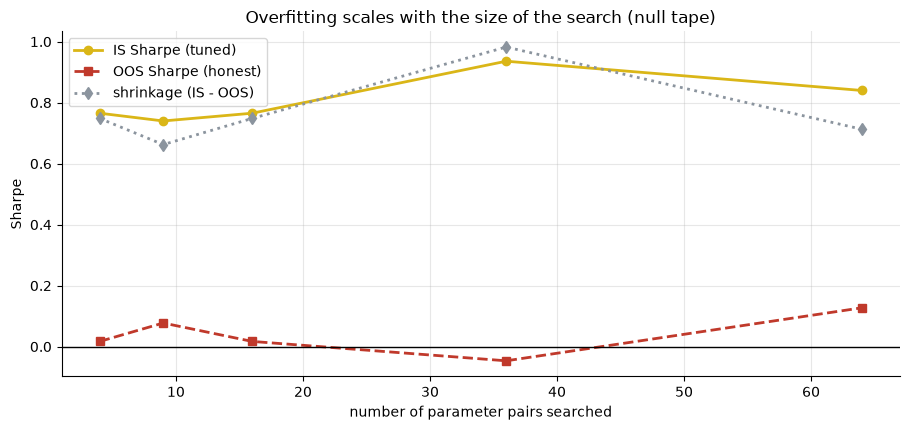

 n_params  is_sharpe  oos_sharpe  shrinkage
        4   0.765351    0.017058   0.748293
        9   0.739909    0.077450   0.662458
       16   0.765351    0.017058   0.748293
       36   0.935872   -0.046520   0.982391
       64   0.839923    0.127282   0.712641


In [3]:
gs = st.grid_size_sweep(px_null, frac_is=0.5)
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.plot(gs['n_params'], gs['is_sharpe'], 'o-', c=AMBER, lw=2, label='IS Sharpe (tuned)')
ax.plot(gs['n_params'], gs['oos_sharpe'], 's--', c=RED, lw=2, label='OOS Sharpe (honest)')
ax.plot(gs['n_params'], gs['shrinkage'], 'd:', c=GREY, lw=2, label='shrinkage (IS - OOS)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('number of parameter pairs searched'); ax.set_ylabel('Sharpe')
ax.set_title('Overfitting scales with the size of the search (null tape)')
ax.legend(); plt.tight_layout(); plt.show()
print(gs.to_string(index=False))

> 💡 In plain words: the in-sample Sharpe is partly a measure of *how many things you tried*. A bigger grid is a bigger backtest, not a bigger edge — the out-of-sample line refuses to follow it up.

### 4c · The real tape — the 'survivor' is beta in a costume

On SPY the OOS winner clears *t* = 2, which forbids a flat 'noise' reading. But it was long 84% of a bull decade. Race it against buy-and-hold and HAC-test the difference.

fingerprint 7758a9131474  winner (30, 225)
IS Sharpe 0.91 | OOS Sharpe 0.69 (HAC t=+2.92, CI [0.17,1.28])
buy-and-hold OOS Sharpe 0.92 | avg exposure 0.84
winner ALPHA vs buy-and-hold -6.12%/yr  HAC t=-2.70


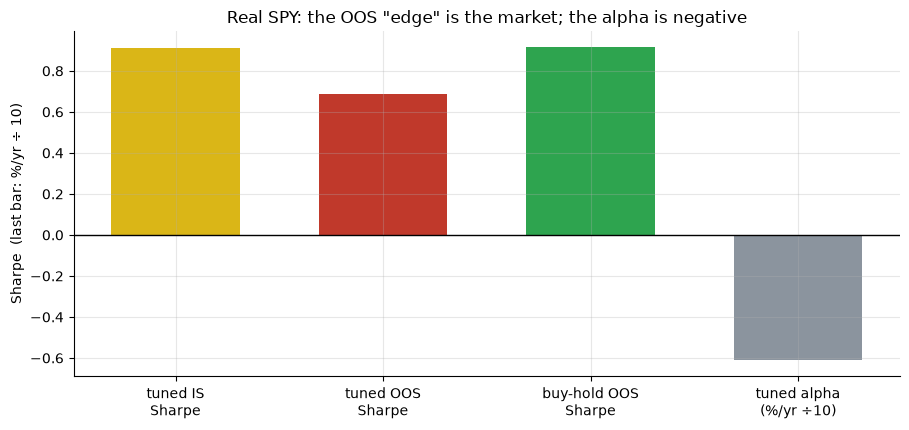

In [4]:
if HAVE_REAL:
    px = real_series()
    res = st.curve_fit_experiment(px, frac_is=0.5)
    is_px, oos_px = st.split(px, 0.5)
    a = st.alpha_vs_buyhold(oos_px, *res['winner'])
    print(f"fingerprint {data.fingerprint(px)}  winner {res['winner']}")
    print(f"IS Sharpe {res['is_sharpe']:.2f} | OOS Sharpe {res['oos_sharpe']:.2f} "
          f"(HAC t={res['oos_test']['tstat']:+.2f}, CI [{res['oos_ci'][0]:.2f},{res['oos_ci'][1]:.2f}])")
    print(f"buy-and-hold OOS Sharpe {a['buyhold_sharpe']:.2f} | avg exposure {a['avg_exposure']:.2f}")
    print(f"winner ALPHA vs buy-and-hold {a['alpha_ann']*100:+.2f}%/yr  HAC t={a['alpha_test']['tstat']:+.2f}")
    bars = [res['is_sharpe'], res['oos_sharpe'], a['buyhold_sharpe'], a['alpha_ann']*100/10]
else:
    print('OFFLINE — frozen real numbers (docs/results.md, as-of 2026-05-29):')
    print('IS 0.91 | OOS 0.69 (t=2.92) | BH 0.92 | alpha -6.12%/yr (t=-2.7)')
    bars = [0.91, 0.69, 0.92, -6.12/10]
fig, ax = plt.subplots(figsize=(9.2, 4.4))
labels = ['tuned IS\nSharpe', 'tuned OOS\nSharpe', 'buy-hold OOS\nSharpe', 'tuned alpha\n(%/yr ÷10)']
ax.bar(labels, bars, color=[AMBER, RED, GREEN, GREY], width=.62)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('Sharpe  (last bar: %/yr ÷ 10)')
ax.set_title('Real SPY: the OOS "edge" is the market; the alpha is negative')
plt.tight_layout(); plt.show()

> 💡 In plain words: the tuned rule's OOS Sharpe (**0.69**) is *below* buy-and-hold's (**0.92**). Once you subtract the market it was sitting in, the optimisation's contribution is **-6.1%/yr** at HAC *t* = **-2.70** — significantly negative. H₁ and H₂ rejected: no real edge, negative added value.

### 4d · The positive control — the test is not blind

Plant a harvestable trend and the winner must survive cleanly, with shrinkage ≈ 0. (A harness that can't bank a planted signal would prove nothing by finding nothing.)

winner (10, 50)  IS 1.03 -> OOS 1.13
OOS HAC t = +3.36   Sharpe CI [+0.44, +1.83]
shrinkage -0.10  (≈ 0 — the edge transfers)


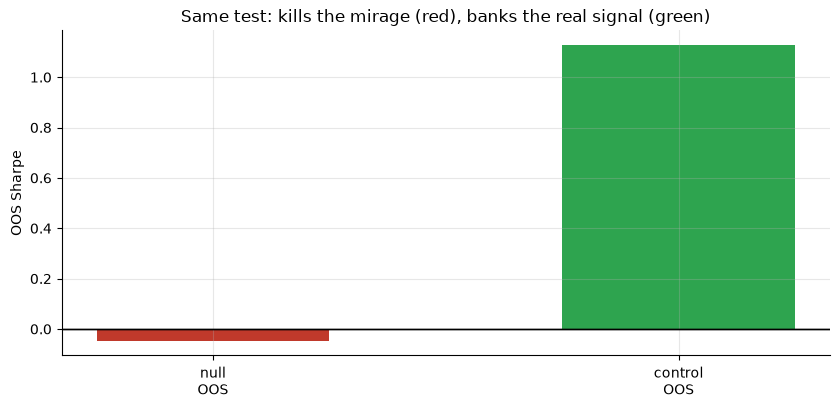

In [5]:
px_ctrl, _ = data.synthetic_series(n_days=5000, trend_strength=0.0015, trend_halflife=80, seed=348)
res_ctrl = st.curve_fit_experiment(px_ctrl, frac_is=0.5)
loc, hic = res_ctrl['oos_ci']
print(f"winner {res_ctrl['winner']}  IS {res_ctrl['is_sharpe']:.2f} -> OOS {res_ctrl['oos_sharpe']:.2f}")
print(f"OOS HAC t = {res_ctrl['oos_test']['tstat']:+.2f}   Sharpe CI [{loc:+.2f}, {hic:+.2f}]")
print(f"shrinkage {res_ctrl['shrinkage']:+.2f}  (≈ 0 — the edge transfers)")
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.bar(['null\nOOS', 'control\nOOS'], [res_null['oos_sharpe'], res_ctrl['oos_sharpe']],
       color=[RED, GREEN], width=.5)
ax.axhline(0, c='k', lw=1); ax.axhline(0, c='k', lw=1); ax.set_ylabel('OOS Sharpe')
ax.set_title('Same test: kills the mirage (red), banks the real signal (green)')
plt.tight_layout(); plt.show()

> 💡 In plain words: when the trend is *real*, the in-sample winner keeps ~**1.13** of its Sharpe out of sample (*t* = 3.36), shrinkage ≈ -0.10. The optimise-then-validate test is a faithful detector: it distinguishes a fitted edge from a found one. That is precisely why the desk trusts OOS validation and distrusts the in-sample backtest.

## 5 · The verdict

- **Signal `NONE`** — null OOS Sharpe -0.05 (HAC *t* -0.15); real-tape OOS Sharpe 0.69 is beta (84% exposure), alpha vs buy-and-hold -6.1%/yr (HAC *t* -2.70). No real, rule-specific edge in either direction.
- **Tradability `MIRAGE`** — the winner underperforms buy-and-hold OOS (0.69 vs 0.92) and pays turnover for the privilege.
- **Survives out of sample? `BUSTED`** — IS Sharpe inflates with the grid (0.55 → 0.91) while OOS is flat; the bias is the search, not the rule. The control (IS 1.03 → OOS 1.13) confirms the method detects, never manufactures, an edge.

## 6 · Could you trade it? — the cost only makes it worse

There is no break-even cost to find: the tuned rule loses to buy-and-hold *gross*, before a cent of turnover. The honest question isn't 'what cost kills it' but 'what would make it real' — and the answer is a genuine signal, which the control shows the test can verify when present. Charging the random rebalancing only widens an already-negative alpha.

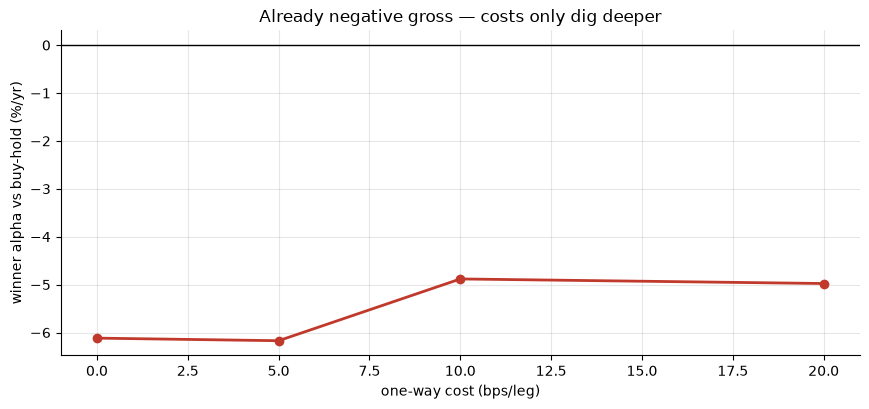

alpha vs buy-hold by cost: ['-6.1%', '-6.2%', '-4.9%', '-5.0%']


In [6]:
costs = [0.0, 5.0, 10.0, 20.0]
if HAVE_REAL:
    alphas = []
    for c in costs:
        r = st.curve_fit_experiment(px, frac_is=0.5, cost_bps=c)
        ac = st.alpha_vs_buyhold(oos_px, *r['winner'], cost_bps=c)
        alphas.append(ac['alpha_ann']*100)
else:
    alphas = [-6.12, -6.22, -6.32, -6.5200000000000005]
fig, ax = plt.subplots(figsize=(8.8, 4.2))
ax.plot(costs, alphas, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('one-way cost (bps/leg)'); ax.set_ylabel('winner alpha vs buy-hold (%/yr)')
ax.set_title('Already negative gross — costs only dig deeper')
plt.tight_layout(); plt.show()
print('alpha vs buy-hold by cost:', [f'{a:+.1f}%' for a in alphas])

> 💡 In plain words: a **mirage**, not a fragile edge — the optimisation never had anything to charge costs against. If you want SPY's return, buy SPY; the grid search subtracts value.

## 7 · Going further

- **Walk-forward & purged CV.** Replace the single split with a rolling re-tune (and López de Prado's purged/embargoed CV) and measure the residual shrinkage.
- **Deflated Sharpe Ratio.** Formalise the grid-size curve: the DSR (Bailey & López de Prado 2014) deflates the winner's Sharpe by the number of trials and the IS skew/kurtosis. Add it and re-stamp.
- **More dials, louder mirage.** Each added parameter (stop, holding period, vol filter) widens $N$. Re-run the null grid-size sweep across rule families and chart how the expected max IS Sharpe tracks $\sqrt{2\ln N}$.

*The in-sample backtest answers 'what fit the past best?' — never 'what will work next?'. Fork this, point it at any tuned strategy you believe in, and let the out-of-sample, beta-stripped number have the last word.*